In [5]:
import sys

print(sys.executable)
print(sys.path)
print(sys.executable)
import DNDSR

print(DNDSR.__dict__)
from DNDSR import DNDS
from test_cfv_dissdisp import WaveTester, default_VRSettings
import numpy as np
import matplotlib.pyplot as plt
import collections

theta = np.pi * 0.0
ax, ay = np.cos(theta), np.sin(theta)
sigma = 0.0
AR = 1
ob = 0


mpi = DNDS.MPIInfo()
mpi.setWorld()
tester = WaveTester(mpi, ax=ax, ay=ay, sigma=sigma, AR=AR, ob=ob)
print(tester.test_one_wave(np.pi * 0.1, 0.0))

/home/harry/projects/DNDSR/venv/bin/python
['/home/harry/projects/DNDSR/test/CFV', '/home/harry/tools/su2code-SU2-1fe5981/install/bin', '/home/harry/anaconda3/lib/python39.zip', '/home/harry/anaconda3/lib/python3.9', '/home/harry/anaconda3/lib/python3.9/lib-dynload', '', '/home/harry/projects/DNDSR/venv/lib/python3.9/site-packages', '/home/harry/projects/DNDSR/src', '/home/harry/projects/DNDSR/src/DNDS', '/home/harry/projects/DNDSR/src/Geom', '/home/harry/projects/DNDSR/src/CFV']
/home/harry/projects/DNDSR/venv/bin/python
{'__name__': 'DNDSR', '__doc__': None, '__package__': 'DNDSR', '__loader__': <_frozen_importlib_external._NamespaceLoader object at 0x7b56953302b0>, '__spec__': ModuleSpec(name='DNDSR', loader=<_frozen_importlib_external._NamespaceLoader object at 0x7b56953302b0>, submodule_search_locations=_NamespacePath(['/home/harry/projects/DNDSR/venv/lib/python3.9/site-packages/DNDSR'])), '__file__': None, '__path__': _NamespacePath(['/home/harry/projects/DNDSR/venv/lib/python3.9


=== DefaultHQM
VariationalReconstruction<dim>::ConstructMetrics() === 
 ===Sum/Min/Max Volume [25;  1, 1]
=== cellSmoothScale min [1]
VariationalReconstruction<dim>::ConstructBaseAndWeight() done
VariationalReconstruction<dim>::ConstructRecCoeff() === A cond Max: [ 7.495e+01] 

=== Factorial
VariationalReconstruction<dim>::ConstructMetrics() === 
 ===Sum/Min/Max Volume [25;  1, 1]
=== cellSmoothScale min [1]
VariationalReconstruction<dim>::ConstructBaseAndWeight() done
VariationalReconstruction<dim>::ConstructRecCoeff() === A cond Max: [ 4.441e+01] 

=== FactorialS0.5
VariationalReconstruction<dim>::ConstructMetrics() === 
 ===Sum/Min/Max Volume [25;  1, 1]
=== cellSmoothScale min [1]
VariationalReconstruction<dim>::ConstructBaseAndWeight() done
VariationalReconstruction<dim>::ConstructRecCoeff() === A cond Max: [ 1.447e+01] 

=== ZCB_OPT0?
VariationalReconstruction<dim>::ConstructMetrics() === 
 ===Sum/Min/Max Volume [25;  1, 1]
=== cellSmoothScale min [1]
VariationalReconstruction<d

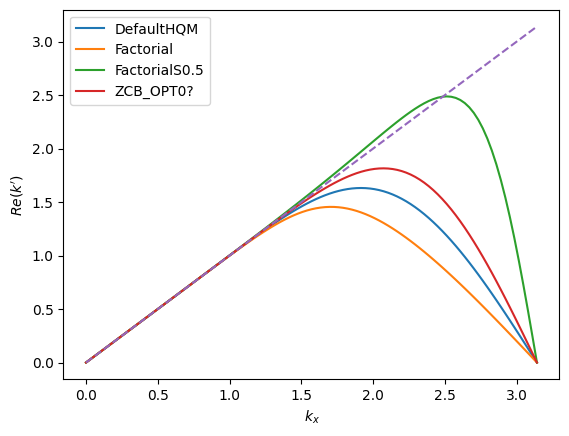

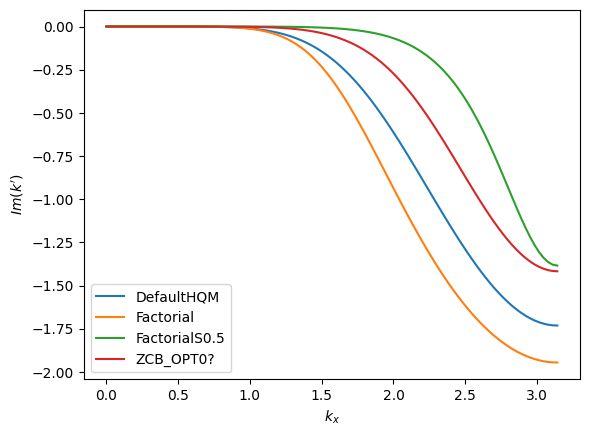

In [6]:
test_configs = [
    "DefaultHQM",
    "Factorial",
    "FactorialS0.5",
    "ZCB_OPT0?",
]

vrSettingsTest = collections.defaultdict(default_VRSettings)
vrSettingsTest["Factorial"]["functionalSettings"]["dirWeightScheme"] = "Factorial"
vrSettingsTest["FactorialS0.5"]["functionalSettings"]["dirWeightScheme"] = "Factorial"
vrSettingsTest["FactorialS0.5"]["functionalSettings"]["scaleMultiplier"] = 0.5
vrSettingsTest["ZCB_OPT0?"]["functionalSettings"]["dirWeightScheme"] = "TEST_OPT"


figR = plt.figure(0)
axR = plt.gca()
figI = plt.figure(1)
axI = plt.gca()
for config_name in test_configs:
    vrSettings = vrSettingsTest[config_name]
    print(f"\n=== {config_name}")
    tester.update_vfv_settings(vrSettings)

    kxs = np.linspace(0, 1, 101) * np.pi
    kappaNum = np.zeros_like(kxs, dtype=np.complex128)
    for ikx, kx in enumerate(kxs):
        kappaNum[ikx] = 1j * tester.test_one_wave(kx, np.pi * 0.0, tol=1e-15)

    axR.plot(kxs, np.real(kappaNum), label=config_name)

    axI.plot(kxs, np.imag(kappaNum), label=config_name)
    
    del kappaNum

axR.plot(kxs, kxs, ls="--")
axI.legend()
axR.legend()
axI.set_ylabel("$Im(k')$")
axR.set_ylabel("$Re(k')$")
axI.set_xlabel("$k_x$")
axR.set_xlabel("$k_x$")

plt.show()

dict_items([('Factorial', {'maxOrder': 3, 'intOrder': 5, 'intOrderVR': 5, 'cacheDiffBase': True, 'jacobiRelax': 1, 'SORInstead': False, 'smoothThreshold': 0.001, 'WBAP_nStd': 10.0, 'normWBAP': False, 'subs2ndOrder': 1, 'subs2ndOrderGGScheme': 0, 'baseSettings': {'localOrientation': False, 'anisotropicLengths': False}, 'functionalSettings': {'dirWeightScheme': 'Factorial', 'geomWeightScheme': 'HQM_SD', 'geomWeightPower': 0.5, 'geomWeightBias': 1, '_tail': 0}}), ('FactorialS0.5', {'maxOrder': 3, 'intOrder': 5, 'intOrderVR': 5, 'cacheDiffBase': True, 'jacobiRelax': 1, 'SORInstead': False, 'smoothThreshold': 0.001, 'WBAP_nStd': 10.0, 'normWBAP': False, 'subs2ndOrder': 1, 'subs2ndOrderGGScheme': 0, 'baseSettings': {'localOrientation': False, 'anisotropicLengths': False}, 'functionalSettings': {'dirWeightScheme': 'Factorial', 'geomWeightScheme': 'HQM_SD', 'geomWeightPower': 0.5, 'geomWeightBias': 1, '_tail': 0, 'scaleMultiplier': 0.5}}), ('ZCB_OPT0?', {'maxOrder': 3, 'intOrder': 5, 'intOrder

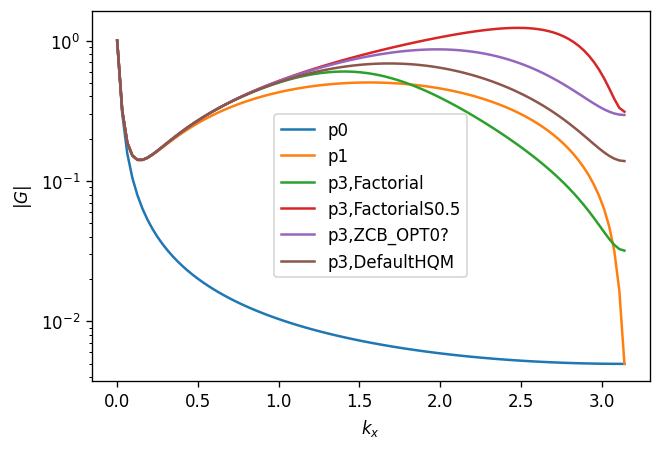

In [7]:
tester.update_eval_settings(sigma=0)


kxs = np.linspace(0, 1, 101) * np.pi

dTauDefault = 100

mg_res_factor = (1.0, 1.0)
mg_dtau_factor = (1.0, 1.0)

def get_conv_rate(
    iter3,
    iter1,
    iter0,
    top_override=-1,
    dTau=dTauDefault,
):
    conv_rate = np.zeros_like(kxs, dtype=np.complex128)
    for ikx, kx in enumerate(kxs):
        conv_rate[ikx] = tester.test_conv_rate(
            dTau,
            kx,
            np.pi * 0.0,
            singlegrid_niter=iter3,
            multigrid_niters=(iter1, iter0),
            use_diff_Jacobi=False,
            top_override=top_override,
            multigrid_res_fact=mg_res_factor,
            multigrid_dtau_fact=mg_dtau_factor,
        )
    return np.abs(conv_rate)


###########
plt.figure(1, figsize=(6, 4), dpi=120)
plt.plot(kxs, get_conv_rate(1, 0, 0, 0), label="p0")
plt.plot(kxs, get_conv_rate(1, 0, 0, 1), label="p1")
# plt.plot(kxs, get_conv_rate(1, 0, 0, -1), label="p3")

for config_name, vrSettings in vrSettingsTest.items():
    print(vrSettingsTest.items())
    tester.update_vfv_settings(vrSettings)
    plt.plot(kxs, get_conv_rate(1, 0, 0, -1), label=f"p3,{config_name}")
leg = plt.legend()
ax = plt.gca()
ax.set_xlim(None, None)
ax.set_yscale("log")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$|G|$")
plt.show()

VariationalReconstruction<dim>::ConstructMetrics() === 
 ===Sum/Min/Max Volume [25;  1, 1]
=== cellSmoothScale min [1]
VariationalReconstruction<dim>::ConstructBaseAndWeight() done
VariationalReconstruction<dim>::ConstructRecCoeff() === A cond Max: [ 7.495e+01] 


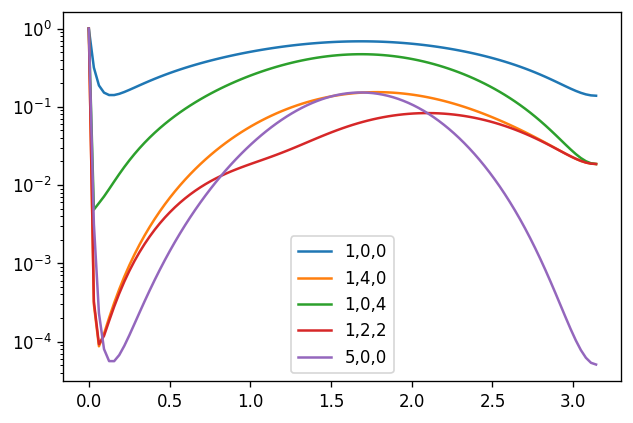

In [ ]:
tester.update_vfv_settings(vrSettingsTest["DefaultHQM"])
# tester.update_vfv_settings(vrSettingsTest["FactorialS0.5"])
mg_res_factor = (
    1,
    1,
)
mg_dtau_factor = (
    0.5,
    0.5,
)
dTau = 100

tests_iters = [
    (1, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
]

tests_iters = [
    (1, 0, 0),
    (3, 0, 0),
    (1, 2, 0),
    (1, 1, 1),
]

tests_iters = [
    (1, 0, 0),
    (1, 4, 0),
    (1, 0, 4),
    (1, 2, 2),
    (5, 0, 0),
]


plt.figure(0, figsize=(6, 4), dpi=120)
for i3, i1, i0 in tests_iters:
    plt.plot(kxs, get_conv_rate(i3, i1, i0, dTau=dTau), label=f"{i3},{i1},{i0}")
leg = plt.legend()

ax = plt.gca()
ax.set_xlim(None, None)
ax.set_yscale("log")
plt.show()